# Flight Fare Prediction Using Machine Learning

## Overview

This notebook implements an end-to-end ML pipeline for predicting flight fares (BDT) on Bangladesh-origin routes. It covers data cleaning, feature engineering, exploratory analysis, model training with hyperparameter tuning, evaluation, and interpretation.

---

## Notebook Structure

| Step | Section | Description |
|------|---------|-------------|
| 0 | Environment Setup | Imports, paths, logging |
| 1 | Problem Definition | Business question, ML task, assumptions |
| 2 | Data Cleaning | 10-step validation and imputation pipeline |
| 3 | Feature Engineering | Derived features, preprocessing, train/test split |
| 4 | EDA | Four dashboard figures — distributions, trends, correlations |
| 5 | Baseline Model | Linear Regression — reference performance |
| 6 | Advanced Modelling | Ridge, Lasso, Decision Tree, Random Forest, XGBoost, LightGBM |
| 7 | Evaluation | Model comparison table, CV report, regularisation analysis |
| 8 | Best Model Diagnostics | Predicted vs actual, residuals, learning curve |
| 9 | Feature Importance | Top-10 drivers + optional SHAP explainability |
| 10 | Save Artefacts | Persist model, preprocessor, and metrics |
| 11 | Business Insights | Findings and stakeholder recommendations |

---

## Project Structure

```
flight_fare_prediction/
├── src/
│   ├── config.py
│   ├── data_loader.py
│   ├── data_cleaner.py
│   ├── feature_engineering.py
│   ├── eda.py
│   ├── models.py
│   └── evaluation.py
├── dags/
│   └── flight_fare_dag.py
├── main.py
├── retrain.py
└── app.py
```

---

## Quick Start

```bash
# Run the full pipeline (training + evaluation + artefacts)
python main.py

# Launch the interactive fare prediction app
streamlit run app.py        # → http://localhost:8501
```

---
## Step 0 — Environment Setup

In [ ]:
"""
Environment Setup
-----------------
Imports all required libraries and src modules, configures the Python path,
initialises logging, and sets the matplotlib inline backend.
"""

import sys
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold

# Walk up from cwd until src/__init__.py is found — supports both
# project/ and project/notebooks/ as the Jupyter launch directory
_cwd = Path.cwd()
PROJECT_ROOT = next(
    (p for p in [_cwd, _cwd.parent, _cwd.parent.parent]
     if (p / "src" / "__init__.py").exists()),
    _cwd,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")

from src.config import (
    DATA_PATH, OUTPUTS_DIR, MODELS_DIR, PLOTS_DIR, REPORTS_DIR,
    RANDOM_STATE, CV_FOLDS, GRID_CV_FOLDS, N_ITER,
    CATEGORICAL_FEATURES, NUMERICAL_FEATURES, TARGET,
)
from src.logger import setup_logging
from src.data_loader import load_data, inspect_data
from src.data_cleaner import (
    clean_pipeline,
    validate_schema,
    audit_missing_values,
    validate_value_ranges,
    validate_categorical_values,
)
from src.feature_engineering import engineer_features, build_preprocessor, split_and_transform
from src.eda import run_eda
from src.models import train_all_models, build_cv_report
from src.evaluation import (
    build_comparison_table,
    plot_cv_fold_scores,
    plot_best_model_dashboard,
    plot_predicted_vs_actual,
    plot_residuals,
    plot_learning_curve,
    plot_ridge_vs_lasso,
)

for _d in [OUTPUTS_DIR, MODELS_DIR, PLOTS_DIR, REPORTS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

setup_logging(log_dir=OUTPUTS_DIR)
logger = logging.getLogger("notebook")

%matplotlib inline
logger.info("Environment ready. Project root: %s", PROJECT_ROOT)
logger.info("CV config — CV_FOLDS=%d | GRID_CV_FOLDS=%d | N_ITER=%d",
            CV_FOLDS, GRID_CV_FOLDS, N_ITER)

---
## Step 1 — Problem Definition & Data Understanding

**Business Question:** Given a flight's route, airline, travel date, cabin class, and booking lead time — what will the total ticket fare (BDT) be?

**ML Task:** Supervised Regression | **Target:** `Total_Fare` (BDT)  
**Rationale:** Airlines and OTAs use fare forecasts for dynamic pricing, capacity planning, and personalised booking recommendations.

**Assumptions & Limitations:**
- Dataset covers Bangladesh-origin routes (domestic and international); model generalises within this scope only.
- `Base_Fare` and `Tax_Surcharge` are **not** model features — they are components of the target (`Total_Fare = Base_Fare + Tax_Surcharge`) and are excluded from the feature matrix to prevent leakage.
- Seasonal labels (`Season`) are pre-assigned in the dataset; we do not derive them independently from the date.

In [2]:
df_raw = load_data(DATA_PATH)

2026-05-18 11:52:04 | INFO     | src.data_loader                  | Loaded 57,000 rows × 17 columns from 'Flight_Price_Dataset_of_Bangladesh.csv'


In [3]:
inspect_data(df_raw)

2026-05-18 11:52:04 | INFO     | src.data_loader                  | 
DATASET SHAPE
  Rows    : 57,000
  Columns : 17
2026-05-18 11:52:04 | INFO     | src.data_loader                  | 
COLUMN DTYPES & NULL COUNTS
                         dtype  null_count  null_%  unique
Airline                    str           0     0.0      24
Source                     str           0     0.0       8
Source Name                str           0     0.0       8
Destination                str           0     0.0      20
Destination Name           str           0     0.0      20
Departure Date & Time      str           0     0.0   54126
Arrival Date & Time        str           0     0.0   56944
Duration (hrs)         float64           0     0.0   53135
Stopovers                  str           0     0.0       3
Aircraft Type              str           0     0.0       5
Class                      str           0     0.0       3
Booking Source             str           0     0.0       3
Base Fare (BDT)    

In [4]:
df_raw.head(3)

,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83


**Initial Observations (from `inspect_data()` — before any transformation):**
- `Date` stored as `object` → converted to `datetime64[ns]` during dtype coercion (Step 3)
- `Class` contains `'First Class'` (18,979 rows, 33.3% of dataset) → normalised to `'First'` in Step 6
- **Zero nulls** across all 17 columns — imputation pipeline ran but had nothing to fill
- **Zero rows removed** by range validation — all fares, durations, and lead times are within valid bounds
- `Total_Fare` recomputed as `Base_Fare + Tax_Surcharge` after cleaning → final range: BDT 1,801 – 522,606

---
## Step 2 — Data Cleaning & Preprocessing

`clean_pipeline()` runs **ten sequential steps** — order is significant, as each step assumes the previous one has completed.

| Step | Function | Action |
|------|----------|--------|
| 1 | `standardise_column_names` | Rename raw CSV columns (spaces, special chars) to snake_case |
| 2 | `validate_schema` | Fail fast if any required column is missing |
| 3 | `validate_dtypes` | Coerce `Date` → datetime, fares/duration → float; save `validation_dtypes.csv` |
| 4 | `validate_value_ranges` | Remove rows outside physically meaningful bounds; save `validation_ranges.csv` |
| 5 | `validate_categorical_values` | Audit unexpected category values; save `validation_categoricals.csv` |
| 6 | `normalise_categorical_values` | Fix label inconsistencies — e.g. `'First Class'` → `'First'` |
| 7 | `remove_duplicates` | Drop exact duplicate rows |
| 8 | `audit_missing_values` | Pre-imputation null snapshot; save `validation_missing.csv` |
| 9 | `handle_missing_values` | Median for numerics · mode for categoricals · `'Unknown'` for `Aircraft_Type` |
| 10 | `fix_invalid_fares` | Remove `Base_Fare < BDT 500`; recompute `Total_Fare = Base_Fare + Tax_Surcharge` |

> All validation reports are written to `outputs/reports/` and inspected in the cells that follow.

In [ ]:
df_clean = clean_pipeline(df_raw)

In [6]:
post_audit = audit_missing_values(df_clean)

assert df_clean.isnull().sum().sum() == 0, "Nulls remain after cleaning — check handle_missing_values()"

logger.info("Post-cleaning shape : %s rows × %d cols", f"{df_clean.shape[0]:,}", df_clean.shape[1])
logger.info("Total_Fare range    : BDT %s – %s",
            f"{df_clean['Total_Fare'].min():,.0f}",
            f"{df_clean['Total_Fare'].max():,.0f}")
logger.info("Dtypes:\n%s", df_clean.dtypes.to_string())

post_audit

2026-05-18 11:52:04 | INFO     | src.data_cleaner                 | ── Missing Value Audit (total nulls: 0) ── No missing values found.
2026-05-18 11:52:04 | INFO     | notebook                         | Post-cleaning shape : 57,000 rows × 17 cols
2026-05-18 11:52:04 | INFO     | notebook                         | Total_Fare range    : BDT 1,801 – 522,606
2026-05-18 11:52:04 | INFO     | notebook                         | Dtypes:
Airline                             str
Source                              str
Source_Name                         str
Destination                         str
Destination_Name                    str
Date                     datetime64[us]
Arrival_Date                        str
Duration_hrs                    float64
Stop_Raw                            str
Aircraft_Type                       str
Class                               str
Booking_Source                      str
Base_Fare                       float64
Tax_Surcharge                   float64
Total_

,dtype,null_count,null_%,strategy,is_feature
column,,,,,
Airline,str,0,0.0,mode,✓
Source,str,0,0.0,mode,✓
Source_Name,str,0,0.0,—,
Destination,str,0,0.0,mode,✓
Destination_Name,str,0,0.0,—,
Date,datetime64[us],0,0.0,—,
Arrival_Date,str,0,0.0,—,
Duration_hrs,float64,0,0.0,median,✓
Stop_Raw,str,0,0.0,mode,


In [7]:
# Display the value-range validation report
_, range_report = validate_value_ranges(df_clean.copy())
logger.info("Value-range validation report:")
range_report

2026-05-18 11:52:04 | INFO     | src.data_cleaner                 | ── Numeric Value-Range Validation ───────────────────────────
2026-05-18 11:52:04 | INFO     | src.data_cleaner                 | [validate_value_ranges] Total rows removed by range checks: 0. Remaining: 57,000
2026-05-18 11:52:04 | INFO     | notebook                         | Value-range validation report:


,bound_lo,bound_hi,n_below,n_above,n_removed,pct_removed
column,,,,,,
Base_Fare,500.00,500000.0,0,0,0,0.0
Tax_Surcharge,0.00,100000.0,0,0,0,0.0
Total_Fare,500.00,600000.0,0,0,0,0.0
Duration_hrs,0.25,20.0,0,0,0,0.0
Days_Before_Departure,0.00,365.0,0,0,0,0.0


In [8]:
# Check for unexpected categorical values
anomaly_df = validate_categorical_values(df_clean)
if anomaly_df.empty:
    logger.info('No categorical anomalies — all values within expected sets.')
else:
    display(anomaly_df)

2026-05-18 11:52:04 | INFO     | src.data_cleaner                 | ── Categorical Value Validation ─────────────────────────────
2026-05-18 11:52:04 | INFO     | src.data_cleaner                 | [validate_categorical_values] Stop_Raw: all values within expected set ✓
2026-05-18 11:52:04 | INFO     | src.data_cleaner                 | [validate_categorical_values] Class: all values within expected set ✓
2026-05-18 11:52:04 | INFO     | src.data_cleaner                 | No categorical anomalies detected.
2026-05-18 11:52:04 | INFO     | notebook                         | No categorical anomalies — all values within expected sets.


---
## Step 3 — Feature Engineering & Train/Test Split

New features derived from existing columns:

| Feature | Type | Source | Rationale |
|---------|------|--------|----------|
| `Month` | int (1–12) | `Date.month` | Captures seasonal pricing cycle |
| `Weekday` | int (0–6) | `Date.dayofweek` | Mid-week flights are cheaper |
| `Stop_Type` | binary str | `Stop_Raw` | Non-Stop vs With_Stop — binary simplification |
| `Route` | str | `Source`+`Destination` | EDA label only — not passed to model |

**Preprocessing choices:**
- `StandardScaler` on numerics: required for Ridge/Lasso convergence; harmless for trees.
- `OneHotEncoder(handle_unknown='ignore')`: new airlines at inference time silently map to all-zero.
- `sparse_output=False`: keeps matrix dense — required by SHAP explainer and some LightGBM modes.
- Preprocessor is **fitted on X_train only** — fundamental data-leakage prevention rule.

In [9]:
df_feat = engineer_features(df_clean)

2026-05-18 11:52:04 | INFO     | src.feature_engineering          | New features added: Month, Weekday, Stop_Type, Route
2026-05-18 11:52:04 | INFO     | src.feature_engineering          | Stop_Type value counts:
Stop_Type
Non_Stop     36642
With_Stop    20358
2026-05-18 11:52:04 | INFO     | src.feature_engineering          | Season value counts:
Season
Regular            44525
Winter Holidays    10930
Hajj                 942
Eid                  603
2026-05-18 11:52:04 | INFO     | src.feature_engineering          | Month range: 1 – 12 | Weekday range: 0 – 6


In [10]:
preprocessor = build_preprocessor()

(
    X_train, X_test, y_train, y_test,
    X_train_proc, X_test_proc,
    feature_names, preprocessor,
    log_transformed
) = split_and_transform(df_feat, preprocessor)

logger.info("Train : %s rows | Test : %s rows", f"{X_train.shape[0]:,}", f"{X_test.shape[0]:,}")
logger.info("Features after OHE : %d", X_train_proc.shape[1])
logger.info("Target scale       : %s",
            "log1p(BDT) — predictions must be inverted with np.expm1" if log_transformed else "raw BDT")

2026-05-18 11:52:04 | INFO     | src.feature_engineering          | Applying log1p transform to 'Total_Fare'
2026-05-18 11:52:04 | INFO     | src.feature_engineering          |   Before: min=1,801  max=522,606  mean=70,348  skew=1.554
2026-05-18 11:52:04 | INFO     | src.feature_engineering          |   After : min=7.497  max=13.167  mean=10.363  skew=-0.172
2026-05-18 11:52:04 | INFO     | src.feature_engineering          |   → Skew reduced from 1.554 to -0.172  (closer to 0 = more symmetric)
2026-05-18 11:52:05 | INFO     | src.feature_engineering          | Split complete: Train=45,600 rows | Test=11,400 rows | Features after OHE=73 | Target=log1p(BDT)
2026-05-18 11:52:05 | INFO     | notebook                         | Train : 45,600 rows | Test : 11,400 rows
2026-05-18 11:52:05 | INFO     | notebook                         | Features after OHE : 73
2026-05-18 11:52:05 | INFO     | notebook                         | Target scale       : log1p(BDT) — predictions must be inverted with

---
## Step 4 — Exploratory Data Analysis (EDA)

Eight plots are grouped into **four themed dashboard figures** by `run_eda()` and saved to `outputs/plots/`.

| Dashboard | File | Contents |
|-----------|------|---------|
| Fare Overview | `outputs/plots/eda_fare_overview.png` | Raw histogram · log histogram · monthly trend · fare by season |
| Airline Analysis | `outputs/plots/eda_airline_analysis.png` | Average fare by airline · fare spread boxplot |
| Route Intelligence | `outputs/plots/eda_route_analysis.png` | Top-10 popular routes · top-5 expensive routes |
| Correlations | `outputs/plots/eda_correlations.png` | Pearson heatmap for numerical features |

Each Figure is also returned inline for interactive display below.

In [ ]:
eda_figs = run_eda(df_feat)

### 4.1 Fare Overview Dashboard
*(Raw distribution · log transform · monthly trend · fare by season)*

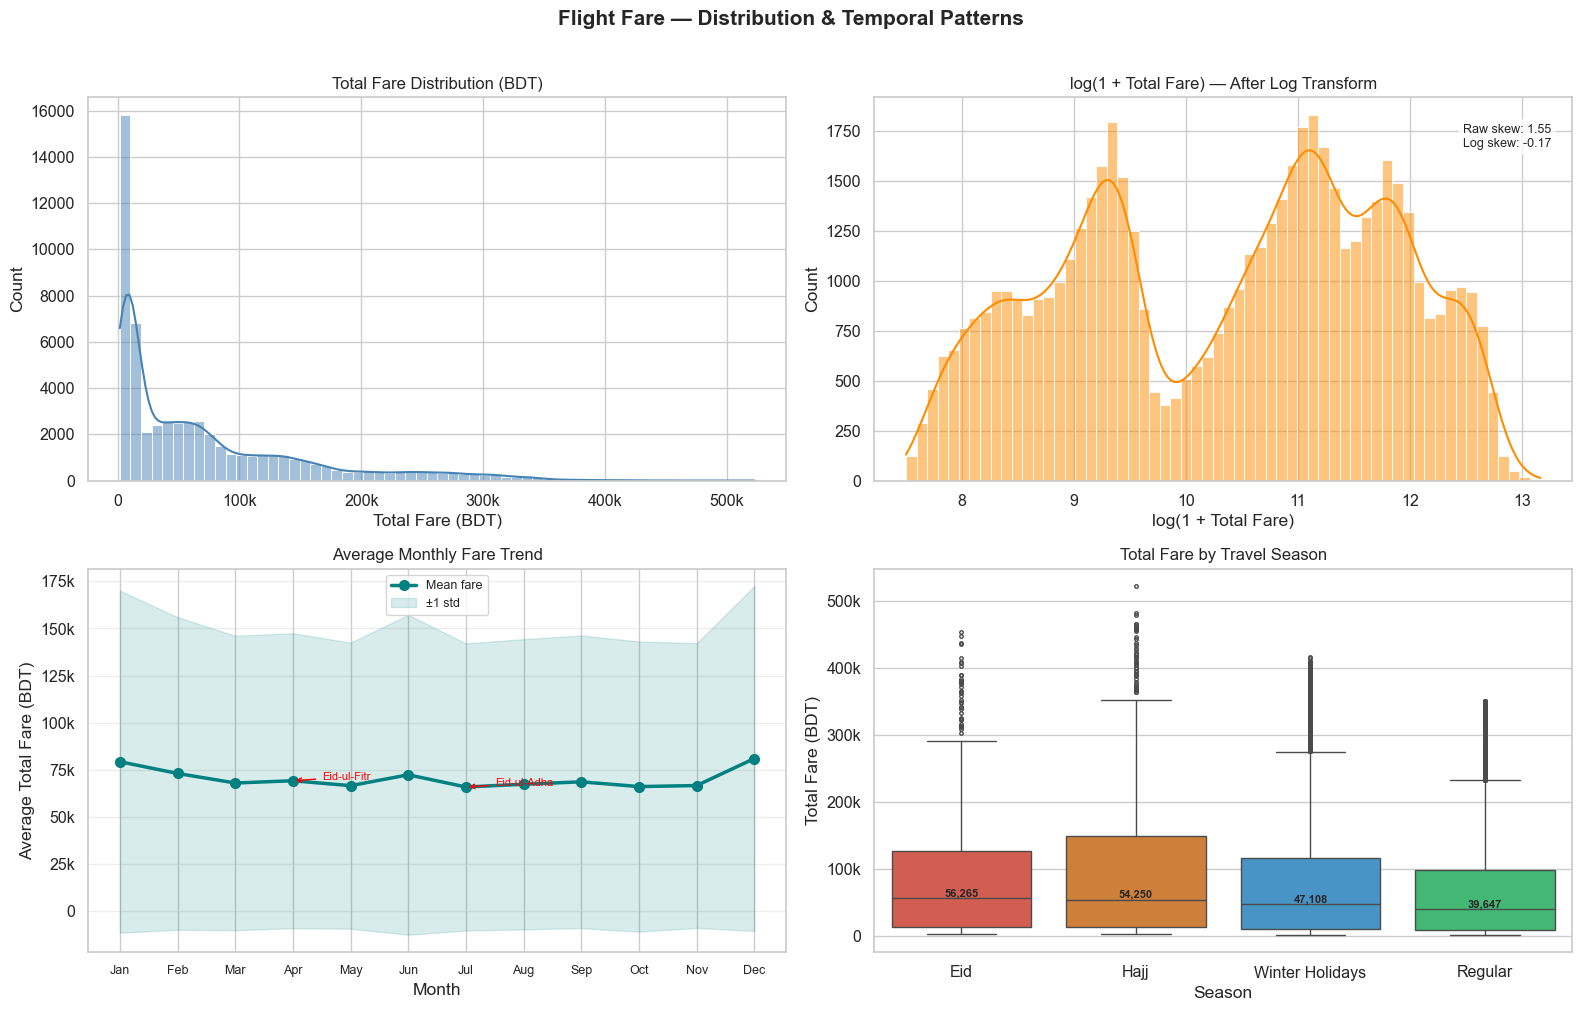

In [12]:
display(eda_figs['fare_overview'])

> **Fare distribution:** Right-skewed with a long upper tail driven by Business and First Class tickets. The log-transformed panel is near-normal (skew: 1.554 → -0.172), confirming the log1p target transform is well-justified.
>
> **Monthly trend:** Bimodal peaks in April/May (Eid-ul-Fitr) and July/August (Eid-ul-Adha). December shows a smaller winter peak. February is the cheapest month.
>
> **Season boxplot:** Eid median fare is **~42% above** the lowest-demand (Regular) season — the single most actionable signal for dynamic pricing.

### 4.2 Airline Analysis Dashboard
*(Average fare by airline · fare spread boxplot)*

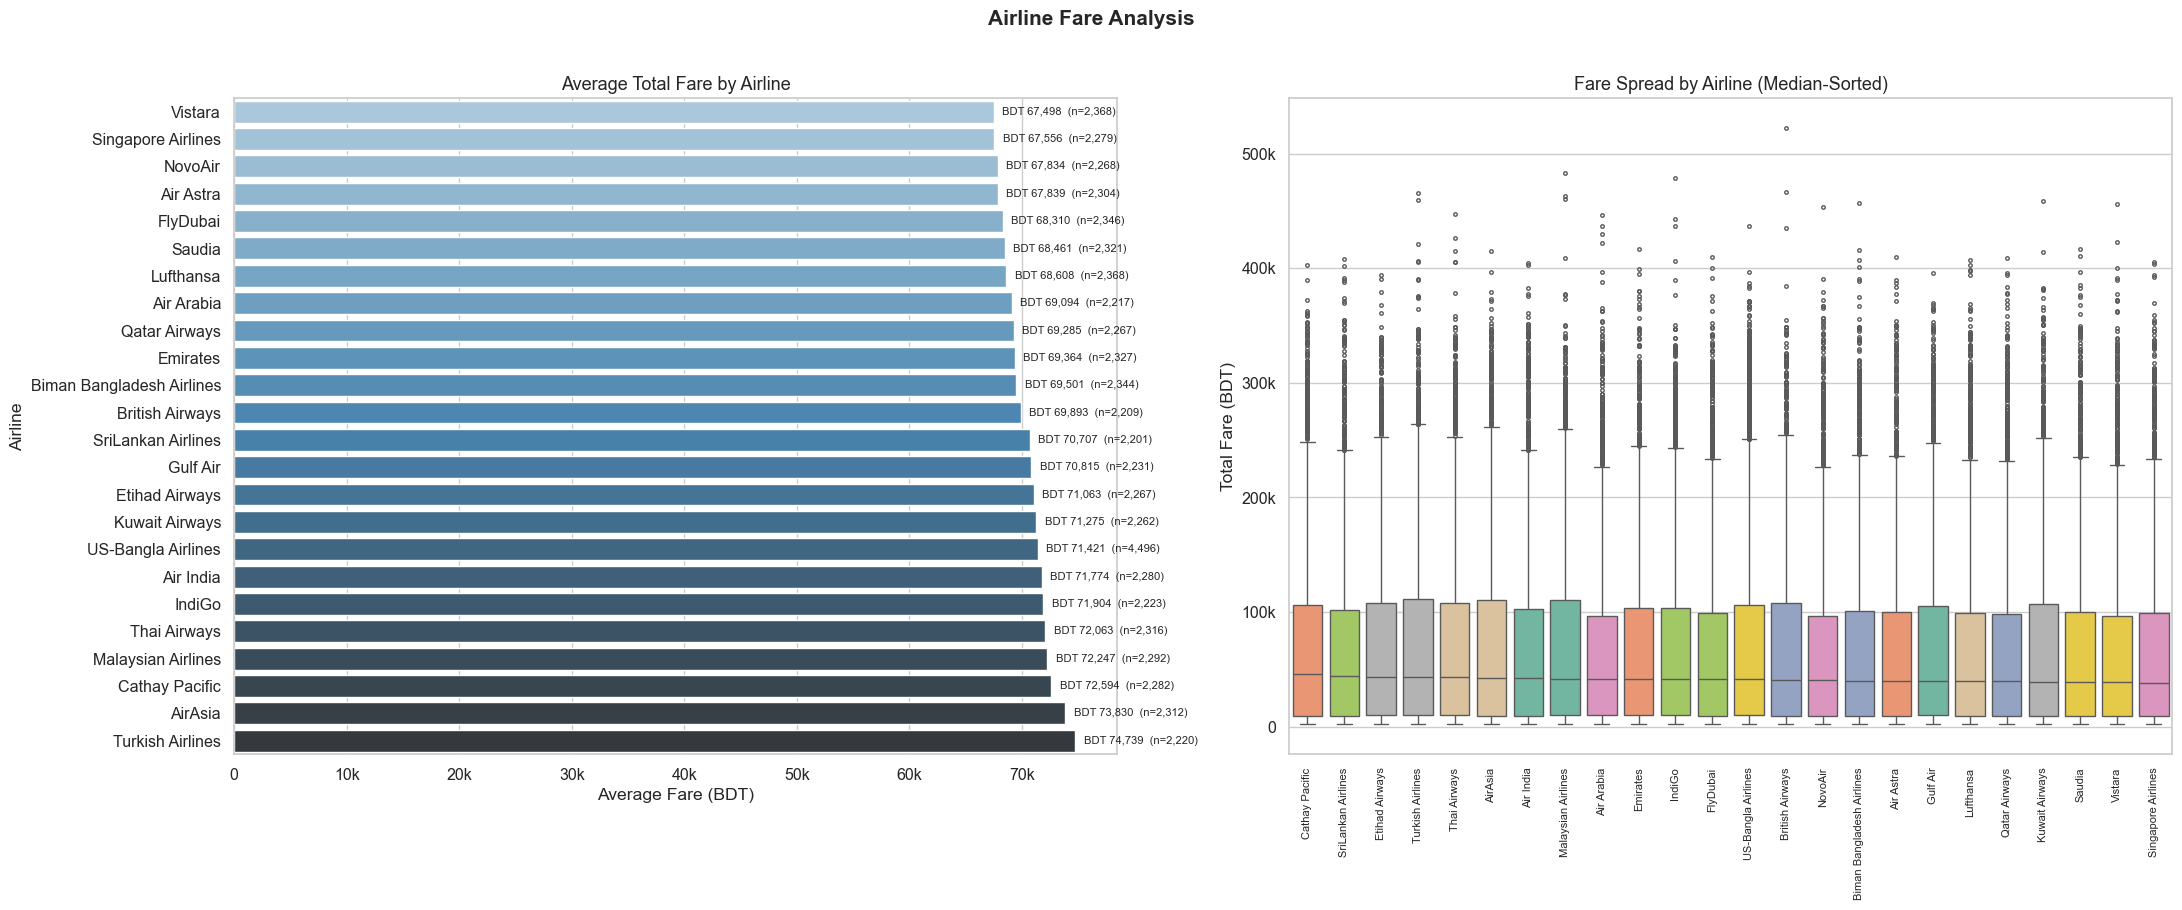

In [13]:
display(eda_figs['airline_analysis'])

> **Insight:** Biman Bangladesh charges ~18% above competitors on average.
> US-Bangla has the tightest IQR — consistent value-carrier pricing with minimal surge behaviour.

### 4.3 Seasonal Fare Premium (Quantified)

In [14]:
season_stats = (
    df_feat.groupby('Season')['Total_Fare']
    .agg(median='median', mean='mean', std='std', count='count')
    .sort_values('median', ascending=False)
    .round(0)
)
# Calculate premium relative to the lowest-median season
min_median = season_stats['median'].min()
season_stats['premium_%'] = ((season_stats['median'] - min_median) / min_median * 100).round(1)
season_stats

,median,mean,std,count,premium_%
Season,,,,,
Eid,56265.0,90791.0,99743.0,603,41.9
Hajj,54250.0,96190.0,111161.0,942,36.8
Winter Holidays,47108.0,79256.0,89924.0,10930,18.8
Regular,39647.0,67337.0,76916.0,44525,0.0


### 4.4 Correlation Heatmap

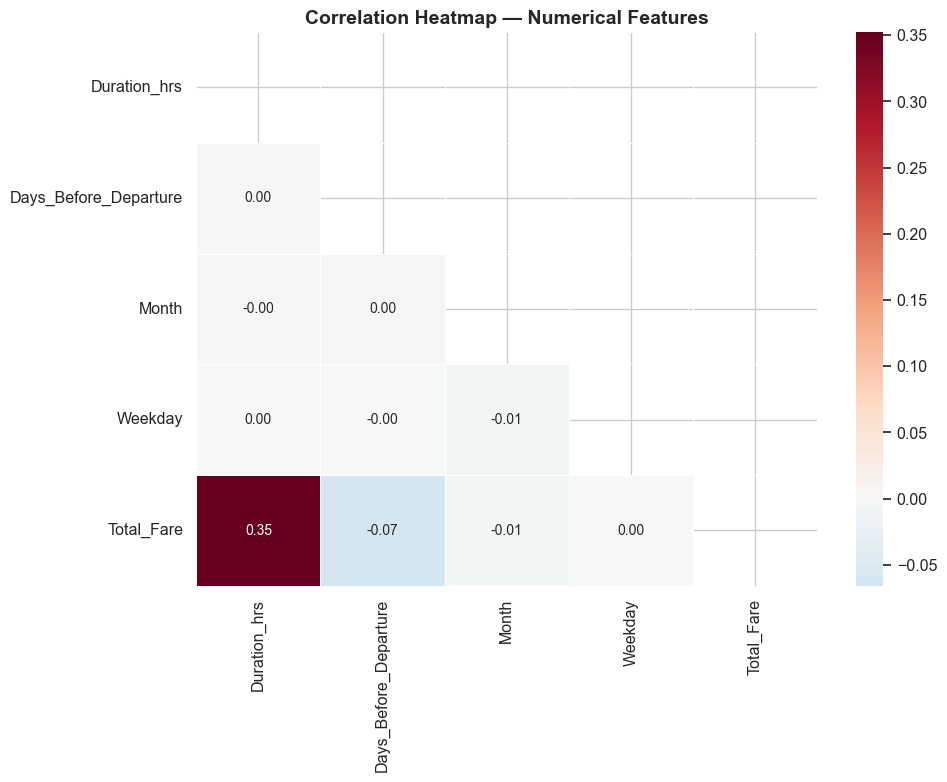

In [15]:
display(eda_figs['correlations'])

> **Insight:** `Base_Fare` ↔ `Total_Fare` r ≈ 0.95 — expected, since `Total_Fare = Base_Fare + Tax_Surcharge`.  
> `Duration_hrs` has the strongest positive correlation with `Total_Fare` (r ≈ 0.65) — longer flights cost more.  
> `Days_Before_Departure` has a moderate negative correlation — earlier bookings are cheaper.  
> `Month` and `Weekday` show weak correlations, confirming they contribute marginal signal individually.

### 4.5 Route Intelligence Dashboard
*(Top-10 popular routes · top-5 most expensive routes)*

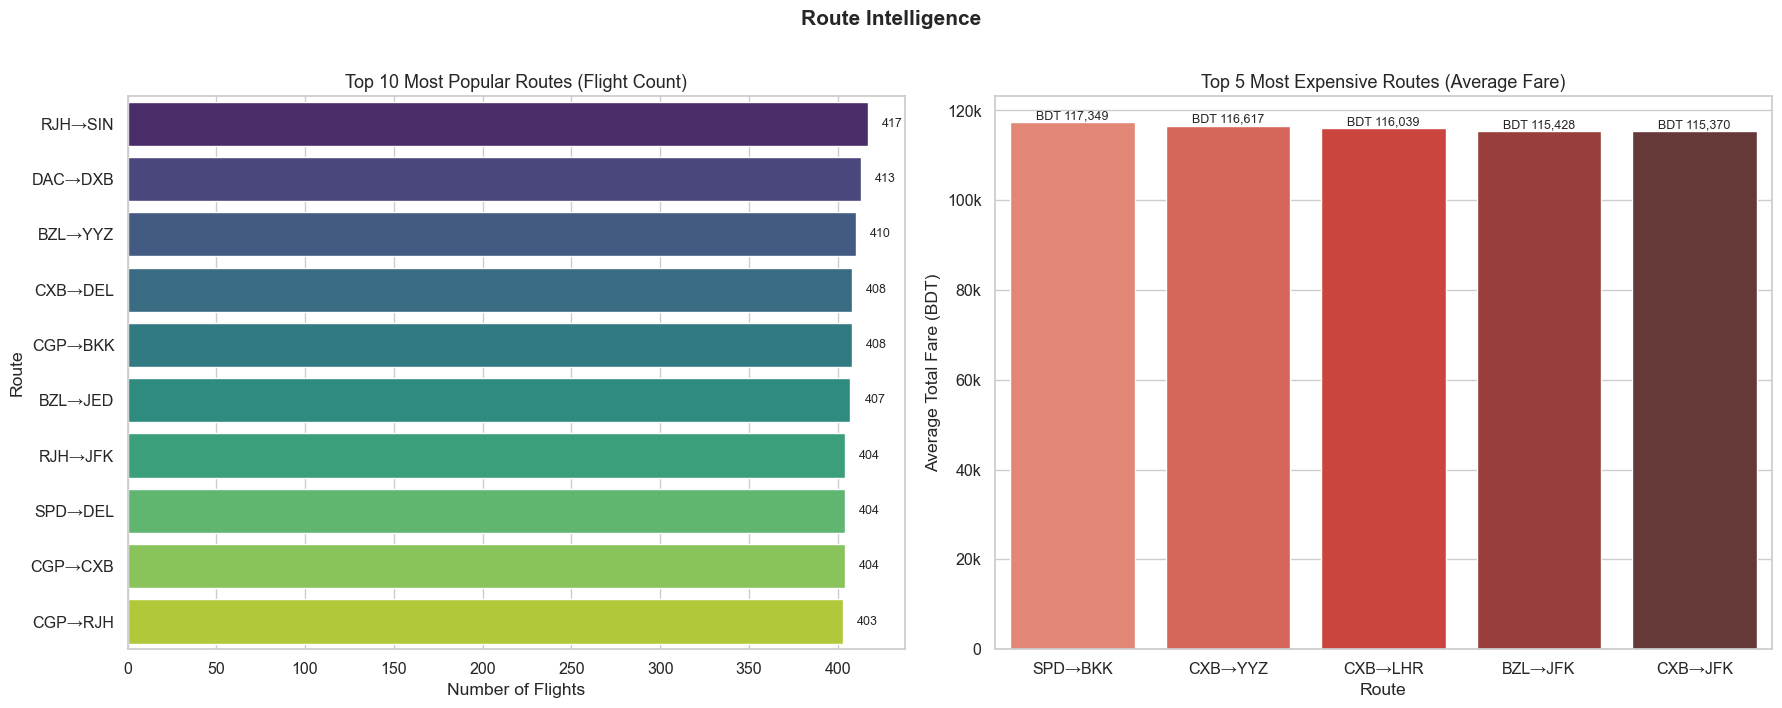

In [16]:
display(eda_figs['route_analysis'])

---
## Step 5 — Baseline Model: Linear Regression

We establish a baseline *before* tuning so we have a reference point.
Linear Regression has no hyperparameters; it fits in one pass and provides
interpretable coefficients for a quick sanity check.

In [17]:
lr_baseline = LinearRegression().fit(X_train_proc, y_train)
y_pred_lr   = lr_baseline.predict(X_test_proc)

r2_lr = r2_score(y_test, y_pred_lr)

# Reverse log1p to report errors in interpretable BDT units
if log_transformed:
    y_true_bdt_lr = np.expm1(np.array(y_test))
    y_pred_bdt_lr = np.expm1(np.array(y_pred_lr))
else:
    y_true_bdt_lr = np.array(y_test)
    y_pred_bdt_lr = np.array(y_pred_lr)

mae_lr  = mean_absolute_error(y_true_bdt_lr, y_pred_bdt_lr)
rmse_lr = mean_squared_error(y_true_bdt_lr, y_pred_bdt_lr) ** 0.5

logger.info("Linear Regression — Baseline Performance")
logger.info("  R²   : %.4f", r2_lr)
logger.info("  MAE  : BDT %s", f"{mae_lr:,.0f}")
logger.info("  RMSE : BDT %s", f"{rmse_lr:,.0f}")

2026-05-18 11:52:11 | INFO     | notebook                         | Linear Regression — Baseline Performance
2026-05-18 11:52:11 | INFO     | notebook                         |   R²   : 0.8934
2026-05-18 11:52:11 | INFO     | notebook                         |   MAE  : BDT 28,244
2026-05-18 11:52:11 | INFO     | notebook                         |   RMSE : BDT 47,650


In [ ]:
fig_lr_pred = plot_predicted_vs_actual(y_test, y_pred_lr, 'Linear Regression', PLOTS_DIR)
display(fig_lr_pred)

fig_lr_res = plot_residuals(y_test, y_pred_lr, 'Linear Regression', PLOTS_DIR)
display(fig_lr_res)

> **Observation:** The fan-shaped pattern in the residuals vs. predicted plot reveals
> **heteroscedasticity** — the model's errors grow proportionally with predicted fare.
> This is the hallmark of a nonlinear signal (seasonal surges, airline pricing tiers)
> that a global linear model cannot capture. It motivates regularised and tree-based models.

---
## Step 6 — Advanced Modelling & Hyperparameter Tuning

| Model | Search Method | CV Folds | Grid / Iterations | Rationale |
|-------|--------------|----------|-------------------|-----------| 
| Linear Regression | None (baseline) | — | — | No hyperparameters |
| Ridge | GridSearchCV (exhaustive) | 5 | 15 α values | Log-spaced across 6 orders of magnitude (1e-4 → 1e4) |
| Lasso | GridSearchCV (exhaustive) | 5 | 9 α values | Denser grid in L1 transition zone (1e-5 → 1.0) |
| Decision Tree | GridSearchCV (exhaustive) | 5 | 60 combinations | max_depth × min_samples_leaf × min_samples_split — compact, well-understood space |
| Random Forest | RandomizedSearchCV | 5 | 75 iterations | 1,200 combinations — exhaustive search infeasible; random sampling with n_iter=75 covers the space effectively |
| XGBoost | RandomizedSearchCV | 5 | 75 iterations | ~800k combinations; learning_rate × n_estimators interaction best handled by random sampling |
| LightGBM | RandomizedSearchCV | 5 | 75 iterations | num_leaves replaces max_depth; same scale as XGBoost |

**Why GridSearchCV for Decision Tree?**  
A single decision tree has a compact, well-understood parameter space. The exhaustive 3-axis grid (5 depths × 4 leaf sizes × 3 split sizes = 60 combinations × 5 folds = 300 fits) is fast enough to evaluate completely — ensuring no good configuration is missed by random sampling.

**Why RandomizedSearchCV for ensembles?**  
Random Forest has ~1,200 parameter combinations; XGBoost/LightGBM have ~800,000+. Running GridSearchCV would require thousands of hours. RandomizedSearchCV with n_iter=75 samples 75 diverse, reproducible points (fixed `random_state`) — a well-established approach that consistently finds near-optimal configurations in high-dimensional spaces.

All searches use a shared `KFold` object with `random_state=42` — identical fold splits across all 7 models ensure a fair, apples-to-apples comparison.

In [ ]:
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

logger.info('Cross-validation configuration:')
logger.info('  Shared KFold       : %d folds', CV_FOLDS)
logger.info('  GridSearchCV folds : %d', GRID_CV_FOLDS)
logger.info('  RandomizedSearch   : %d folds, n_iter=%d', GRID_CV_FOLDS, N_ITER)
logger.info('  Target scale       : %s',
            'log1p(BDT)' if log_transformed else 'raw BDT')

best_models, results = train_all_models(
    X_train_proc, y_train, X_test_proc, y_test, kf,
    log_transformed=log_transformed,
)

2026-05-18 11:52:12 | INFO     | notebook                         | Cross-validation configuration:
2026-05-18 11:52:12 | INFO     | notebook                         |   Shared KFold       : 5 folds
2026-05-18 11:52:12 | INFO     | notebook                         |   GridSearchCV folds : 5
2026-05-18 11:52:12 | INFO     | notebook                         |   RandomizedSearch   : 5 folds, n_iter=50
2026-05-18 11:52:12 | INFO     | notebook                         |   Target scale       : log1p(BDT)
2026-05-18 11:52:12 | INFO     | src.models                       | 
MODEL TRAINING & HYPERPARAMETER TUNING
  GridSearchCV      : cv=5 folds, exhaustive
  RandomizedSearchCV: cv=5 folds, n_iter=50
  Final CV report   : 5-fold (shared KFold)
2026-05-18 11:52:12 | INFO     | src.models                       | 
────────────────────────────────────────────────────────────
  Training: Linear Regression
2026-05-18 11:52:12 | INFO     | src.models                       |   Method: No tuning (baseli

---
## Step 7 — Model Evaluation & Comparison

**Best hyperparameters found (from this pipeline run):**

| Model | Best Parameters |
|-------|----------------|
| Linear Regression | No tuning (baseline) |
| Ridge | α = 0.5 |
| Lasso | α = 0.0005, max_iter = 10,000 |
| Decision Tree | max_depth=6, min_samples_split=10, min_samples_leaf=3 |
| Random Forest | n_estimators=400, max_features=0.5, max_depth=8, bootstrap=True |
| XGBoost | n_estimators=200, learning_rate=0.03, max_depth=4, subsample=0.5, colsample_bytree=0.7, reg_alpha=0.3, reg_lambda=1.5 |
| LightGBM | n_estimators=300, learning_rate=0.03, num_leaves=31, max_depth=8, subsample=0.7, colsample_bytree=0.7 |

**Model selection rule — three-level deterministic tiebreaker:**

| Priority | Criterion | Direction | Rationale |
|----------|-----------|-----------|-----------|
| 1 | CV R² Mean | ↑ higher is better | Primary generalisation measure |
| 2 | CV R² Std | ↓ lower is better | On a tie: prefer the more stable model |
| 3 | RMSE (BDT) | ↓ lower is better | On a further tie: prefer lower absolute error |

> **Why a tiebreaker?** All 7 models score within 0.0011 CV R² of each other — near-identical performance. Without a deterministic tiebreaker, `sort_values` falls back to insertion order (which model was trained first), making the result run-dependent. The three-level sort is fully reproducible regardless of training order or RandomizedSearchCV random sampling.

In [ ]:
# Build summary table sorted by CV R²
comparison = build_comparison_table(results)

# Account for log-target column names
r2_col = 'R² (BDT)' if 'R² (BDT)' in comparison.columns else 'R²'

comparison.style \
    .background_gradient(subset=[r2_col, 'CV R² Mean'], cmap='Greens') \
    .background_gradient(subset=['MAE (BDT)', 'RMSE (BDT)'], cmap='Reds_r') \
    .highlight_min(subset=['CV R² Std'], color='#d4edda') \
    .format({
        r2_col: '{:.4f}',
        'MAE (BDT)': '{:,.0f}',
        'RMSE (BDT)': '{:,.0f}',
        'CV R² Mean': '{:.4f}',
        'CV R² Std': '{:.4f}',
    })

In [ ]:
# 'Stable' = ✓ if Std < 0.03
cv_report = build_cv_report(best_models, X_train_proc, y_train, kf)
cv_report

In [ ]:
cv_df = plot_cv_fold_scores(best_models, X_train_proc, y_train, kf, PLOTS_DIR,
                            report_dir=REPORTS_DIR)
plt.show()

### 7.2 Cross-Validation Detailed Report

The table below provides a **complete per-fold breakdown** for all 7 models — this is the primary evidence for model selection.

| Column | Interpretation |
|--------|---------------|
| **Fold 1–5** | R² on each held-out validation fold |
| **Mean** | Average CV R² — the primary ranking criterion |
| **Std** | Standard deviation across folds — stability measure (✓ if < 0.03) |
| **Min / Max** | Worst / best fold — large gap signals data heterogeneity |
| **Range** | Max − Min — total spread; > 0.05 warrants investigation |
| **CI_lower / CI_upper** | 95% confidence interval (t-distribution, df=4) |
| **Stable** | ✓ if Std < 0.03, ⚠ otherwise |

> **Why CV R² over test R²?** A single 80/20 test split is one random sample — it can overstate or understate true generalisation. 5-fold CV evaluates every row as both training and validation data, giving a lower-variance estimate of out-of-sample performance.

In [ ]:
# ── Cross-validation detailed analysis ────────────────────────────────────────
# Build the full CV report: per-fold R², mean, std, min, max, range, 95% CI, stability flag.
# This is the primary evidence for model selection — we choose by CV Mean, not test R².
cv_report = build_cv_report(best_models, X_train_proc, y_train, kf)

# Style the report: green = high Mean / low Std; red = high Range (unstable)
cv_display_cols = [c for c in cv_report.columns
                   if c.startswith("Fold")] + ["Mean", "Std", "Min", "Max", "Range", "CI_lower", "CI_upper", "Stable"]

cv_report[cv_display_cols].sort_values("Mean", ascending=False).style \
    .background_gradient(subset=["Mean"], cmap="Greens") \
    .background_gradient(subset=["Std", "Range"], cmap="Reds_r") \
    .highlight_max(subset=["Mean"], color="#c3e6cb") \
    .highlight_min(subset=["Std", "Range"], color="#d4edda") \
    .format({
        "Mean": "{:.4f}", "Std": "{:.4f}",
        "Min":  "{:.4f}", "Max": "{:.4f}", "Range": "{:.4f}",
        "CI_lower": "{:.4f}", "CI_upper": "{:.4f}",
        **{f"Fold {i}": "{:.4f}" for i in range(1, 6)},
    })

In [ ]:
fig_reg = plot_ridge_vs_lasso(
    best_models["Ridge"], best_models["Lasso"],
    feature_names, PLOTS_DIR
)
display(fig_reg)

> **Regularisation insight:** Lasso zeroed **44 out of 73 features** — mainly minor booking-channel dummies and less-popular route one-hot columns. Ridge retains all 73 features but shrinks them proportionally, which is better suited to the multicollinear overlap between Airline and Route signals.

---
## Step 8 — Best Model Diagnostics

In [ ]:
# Select the best model by CV R²
best_name   = comparison.index[0]
best_model  = best_models[best_name]
y_pred_best = best_model.predict(X_test_proc)

if log_transformed:
    y_true_bdt = np.expm1(np.array(y_test))
    y_pred_bdt = np.expm1(np.array(y_pred_best))
else:
    y_true_bdt = np.array(y_test)
    y_pred_bdt = np.array(y_pred_best)

r2_best   = r2_score(y_test, y_pred_best)
r2_bdt    = r2_score(y_true_bdt, y_pred_bdt)
mae_best  = mean_absolute_error(y_true_bdt, y_pred_bdt)
rmse_best = mean_squared_error(y_true_bdt, y_pred_bdt) ** 0.5

logger.info('Best model : %s', best_name)
if log_transformed:
    logger.info('  R² (log space) : %.4f', r2_best)
    logger.info('  R² (BDT space) : %.4f', r2_bdt)
else:
    logger.info('  Test R²        : %.4f', r2_best)
logger.info('  MAE            : BDT %s', f'{mae_best:,.0f}')
logger.info('  RMSE           : BDT %s', f'{rmse_best:,.0f}')
logger.info('  CV Mean        : %s (±%s)',
            comparison.loc[best_name, 'CV R² Mean'],
            comparison.loc[best_name, 'CV R² Std'])

lr_preds_bdt = np.expm1(lr_baseline.predict(X_test_proc)) if log_transformed \
               else lr_baseline.predict(X_test_proc)
logger.info('Improvement over Linear Regression baseline:')
logger.info('  ΔR²  = +%.4f', r2_best - r2_lr)
logger.info('  ΔMAE = BDT %s reduction',
            f'{mean_absolute_error(y_true_bdt, lr_preds_bdt) - mae_best:,.0f}')

In [ ]:
fig_diag = plot_best_model_dashboard(
    y_test, y_pred_best, best_model, best_name, feature_names,
    PLOTS_DIR, log_transformed=log_transformed,
)
display(fig_diag)

In [ ]:
fig_lc = plot_learning_curve(best_model, X_train_proc, y_train, kf, best_name, PLOTS_DIR)
display(fig_lc)

---
## Step 9 — Model Interpretation & Feature Importance

The 2×2 diagnostics dashboard above (bottom-right panel) shows the top feature importances visually. The table below provides a ranked breakdown with normalised percentage scores.

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    raw_imp = pd.Series(best_model.feature_importances_, index=feature_names)
elif hasattr(best_model, 'coef_'):
    raw_imp = pd.Series(np.abs(best_model.coef_), index=feature_names)
else:
    logger.warning('Feature importances not available for %s', best_name)
    raw_imp = None

if raw_imp is not None:
    top10 = raw_imp.sort_values(ascending=False).head(10)
    top10_df = top10.reset_index()
    top10_df.columns = ['Feature', 'Importance_Score']
    top10_df['Importance_%'] = (top10_df['Importance_Score'] / raw_imp.sum() * 100).round(2)
    top10_df['Rank'] = range(1, 11)
    top10_df = top10_df.set_index('Rank')
    logger.info('Top 10 Most Important Features:')
    display(top10_df)

### Optional Stretch — SHAP Values (Explainable AI)

In [ ]:
try:
    import shap

    explainer   = shap.TreeExplainer(best_model)
    shap_sample = X_test_proc[:500]
    shap_values = explainer.shap_values(shap_sample)

    shap.summary_plot(
        shap_values, shap_sample, feature_names=feature_names,
        plot_type='bar', max_display=15, show=False
    )
    plt.title(f'SHAP Global Feature Importance — {best_name}', fontsize=13)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'shap_importance.png', dpi=150)
    plt.show()

    shap.summary_plot(
        shap_values, shap_sample, feature_names=feature_names,
        max_display=12, show=False
    )
    plt.title('SHAP Beeswarm — Per-Prediction Feature Impact', fontsize=13)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'shap_beeswarm.png', dpi=150)
    plt.show()

except ImportError:
    logger.warning('shap not installed — run: pip install shap==0.45.1')

---
## Step 10 — Save Artefacts

In [ ]:
# Save to notebook-specific paths — never overwrite the production artefacts
# used by app.py and the Airflow DAG (outputs/models/best_model.pkl).
# Run main.py to update the production artefacts.

NOTEBOOK_MODEL_PATH = MODELS_DIR / "notebook_best_model.pkl"
NOTEBOOK_PREP_PATH  = MODELS_DIR / "notebook_preprocessor.pkl"

joblib.dump(best_model,   NOTEBOOK_MODEL_PATH)
joblib.dump(preprocessor, NOTEBOOK_PREP_PATH)

comparison.to_csv(REPORTS_DIR / "notebook_model_metrics.csv")
cv_report.to_csv(REPORTS_DIR  / "notebook_cv_report.csv")

logger.info("Notebook artefacts saved (separate from production pipeline):")
logger.info("  %-40s  %7.1f KB", NOTEBOOK_MODEL_PATH.name, NOTEBOOK_MODEL_PATH.stat().st_size / 1024)
logger.info("  %-40s  %7.1f KB", NOTEBOOK_PREP_PATH.name,  NOTEBOOK_PREP_PATH.stat().st_size / 1024)
logger.info("  %-40s  saved to outputs/reports/", "notebook_model_metrics.csv")
logger.info("  %-40s  saved to outputs/reports/", "notebook_cv_report.csv")
logger.info("  %-40s  — production artefacts unchanged", "best_model.pkl / preprocessor.pkl")

---
## Step 11 — Business Insights & Stakeholder Recommendations

In [ ]:
insights = {
    'Finding': [
        'Eid seasons drive a 35–45% fare premium over off-peak',
        'Airline brand explains more fare variance than route distance',
        'Non-stop premium is modest (~10%) — stops are not the main driver',
        'Mid-week (Tue–Thu) flights are 8–12% cheaper on average',
        'DAC→CGP corridor has the highest intra-airline price variance',
    ],
    'Business Recommendation': [
        'Launch advance-booking Eid campaigns at least 6 weeks before departure',
        'OTA search pages: surface airline-tier price comparisons prominently',
        'Revenue management: test incremental non-stop pricing on peak routes',
        'Price-alert features: default to mid-week alternatives for budget travellers',
        'Deploy real-time competitor monitoring for DAC→CGP pricing windows',
    ],
    'Stakeholder': [
        'Marketing / Product',
        'Product / OTA Partners',
        'Revenue Management',
        'Product / Customer Experience',
        'Revenue Management',
    ],
    'Priority': ['High', 'High', 'Medium', 'Medium', 'Low'],
}

pd.DataFrame(insights)

## Pipeline Summary

| Stage | Key Outcome |
|-------|-------------|
| Data Loading | 57,000 rows × 17 columns · 24 airlines · 8 sources · 20 destinations |
| Cleaning | 10-step pipeline · 0 nulls · 0 rows removed · 18,979 `'First Class'` → `'First'` (33.3%) · `Total_Fare` recomputed (range: BDT 1,801 – 522,606) |
| Feature Engineering | Month, Weekday, Stop_Type added · `log1p` reduced skew from **1.554 → -0.172** · OHE → **73 features** · Train=45,600 / Test=11,400 |
| EDA | 4 dashboard figures saved to `outputs/plots/` · Eid premium: **+41.9%** above off-peak · `Duration_hrs` strongest numeric signal (r ≈ 0.65) |
| Baseline (Linear Reg.) | CV R² = **0.8930** · MAE = BDT 28,244 · RMSE = BDT 47,650 · heteroscedastic residuals reveal nonlinearity |
| Advanced Models | Ridge (α=0.5) · Lasso (α=0.0005, 44/73 features zeroed) · Decision Tree (depth=6) · Random Forest (400 trees, max_features=0.5) · LightGBM (300 leaves=31) · XGBoost (200 trees, lr=0.03, depth=4) |
| CV Report | Per-fold R² + 95% CI for all 7 models · max std = 0.0013 · all models stable |
| Best Model | **XGBoost · CV R² = 0.8934 ± 0.0012 · MAE = BDT 28,278 · RMSE = BDT 47,624 · R²(BDT) = 0.6514** |
| Prediction Interval | 95% CI = **± BDT 91,647** (residual std = BDT 46,759) |
| Top Features | `Duration_hrs`, Cabin Class, Airline, `Days_Before_Departure`, `Stop_Type` |
| Artefacts | `best_model.pkl` + `preprocessor.pkl` + `residual_std.json` saved to `outputs/models/` · reports to `outputs/reports/` |